---
title: "Pretrain a Tabular Foundation Model from Scratch"
description: "Build a small TabPFN-style model, generate synthetic pretraining tables on the fly, train it in minutes, and evaluate it zero-shot on real datasets"
icon: "flask"
cookbookTags:
  - pretraining
  - classification
authors:
  - name: Philipp Singer
---

*Watch a tiny TabPFN learn in-context prediction from synthetic tables alone.*

This cookbook is fully self-contained: it builds a small **TabPFN-style** tabular foundation model (nanoTabPFN), generates its synthetic pretraining data **on the fly**, trains it for a few minutes, and evaluates the result on real datasets it has never seen.

The whole pipeline is here, in this order:

1. **The prior** – a random program that produces endless synthetic classification tables.
2. **The architecture** – a transformer that attends across rows *and* across columns of a table.
3. **In-context inference** – a `fit` / `predict_proba` wrapper that does *no* gradient steps.
4. **Pretraining** – the model learns to do Bayesian prediction on tables drawn from the prior.
5. **Evaluation** – zero-shot performance on iris, wine and breast cancer.

The model and training loop are a condensed version of **nanoTabPFN** ([github.com/automl/nanotabpfn](https://github.com/automl/nanotabpfn)), a minimal re-implementation of the TabPFN v2 architecture. The surrounding tooling (prior interfaces, evaluation pipeline, pre-generated prior dumps) lives in the **TFM-Playground** ([github.com/automl/TFM-Playground](https://github.com/automl/TFM-Playground)). This notebook re-implements the pieces it needs so that it runs on its own.

> This is a teaching model, not the production TabPFN. To use the pretrained TabPFN on your own data, see the other cookbooks.

## Setup

Everything runs on plain PyTorch. A GPU (or Apple Silicon) makes pretraining faster, but a CPU works too. In Colab, pick a GPU runtime under *Runtime → Change runtime type*.

In [1]:
import importlib.util

required = ("torch", "numpy", "sklearn", "matplotlib", "schedulefree")
if not all(importlib.util.find_spec(package) for package in required):
    %pip install -q torch numpy scikit-learn matplotlib schedulefree

In [2]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn

# ---------------------------------------------------------------- configuration
EPOCHS = 80
STEPS_PER_EPOCH = 25
BATCH_SIZE = 50
LR = 1e-4
NUM_ROWS = 50  # datapoints per synthetic table
NUM_FEATURES = 3  # columns per synthetic table
MAX_CLASSES = 3

SEED = 2402
torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("device:", device)

device: mps


## The prior: where the training data comes from

A tabular foundation model is **never trained on real datasets**. Instead we write down a *prior* over
"plausible tables": a random program that, each time it is called, invents a brand-new dataset.
Here each table is produced by

1. drawing `NUM_ROWS` input rows $x \sim \mathcal{N}(0, I)$ with `NUM_FEATURES` columns,
2. drawing a **random neural network** $f$ (random depth, width, activation, sparse weights) and computing $f(x)$ plus noise,
3. cutting the scalar output at random quantiles into 2 or 3 **classes**, and shuffling the class ids.

Every call yields a different function, so the model can never memorise. It has to learn the *algorithm*:
"look at the labelled rows, infer the underlying function, predict the unlabelled rows".

The generator returns exactly one dictionary per training step:
`x` (batch, rows, features), `y` (batch, rows) and the index that separates the labelled "train" rows from the
"test" rows the model must predict.

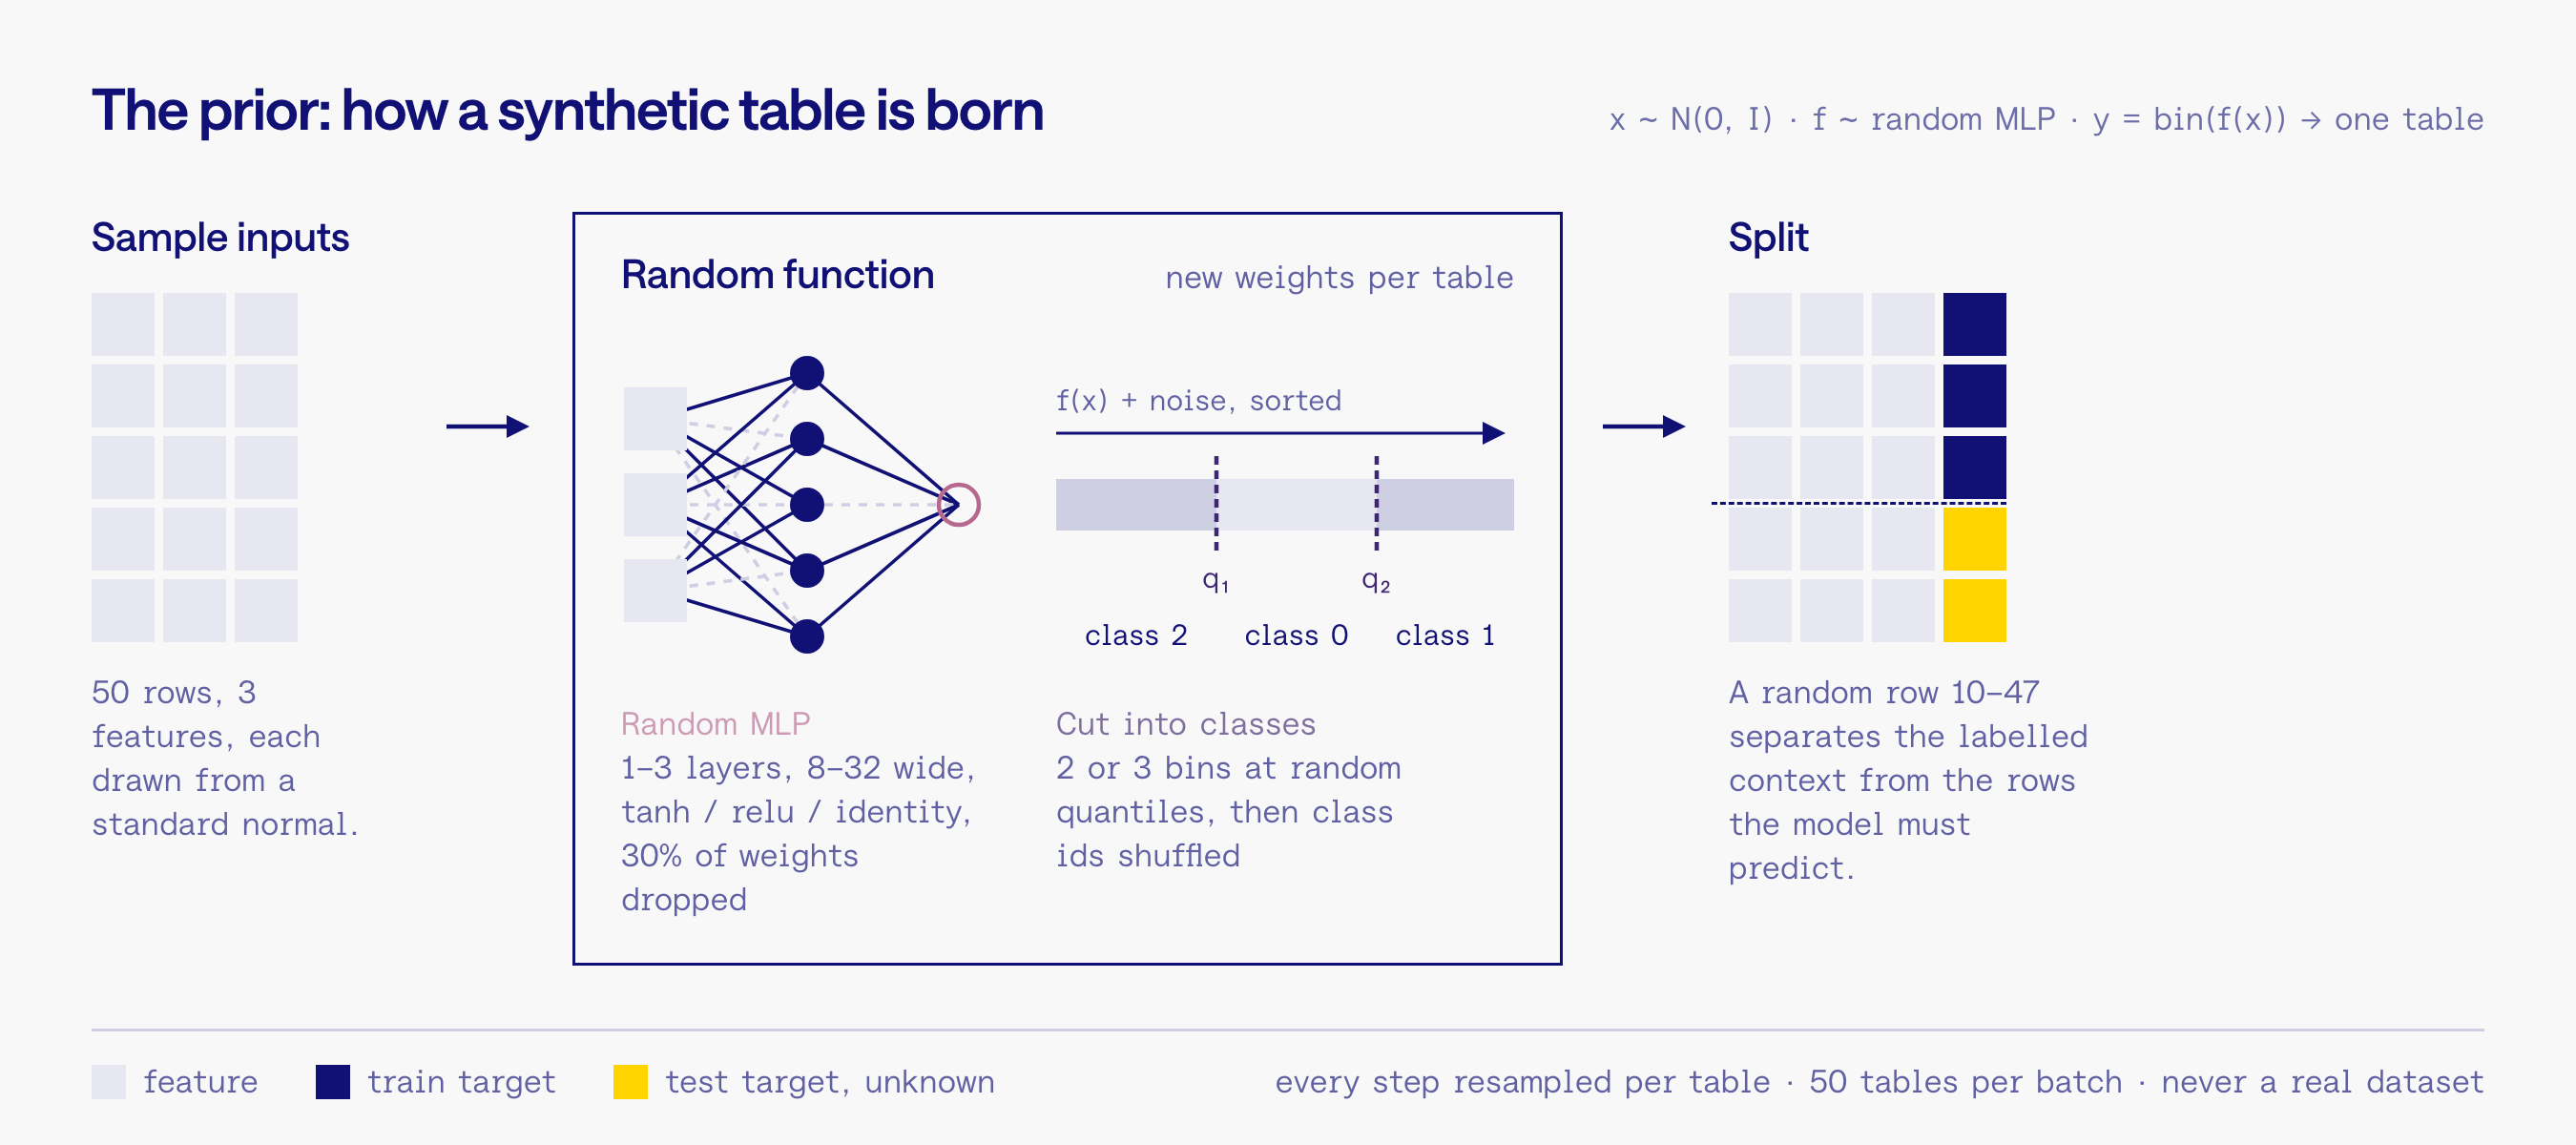

In [3]:
def sample_prior_batch(batch_size, num_rows=NUM_ROWS, num_features=NUM_FEATURES, max_classes=MAX_CLASSES, gen=None):
    '''Generates a batch of synthetic classification tables from a random-MLP prior (all on CPU, fully batched).'''
    B = batch_size
    rint = lambda lo, hi, *shape: torch.randint(lo, hi + 1, shape, generator=gen)

    # --- 1. inputs
    x = torch.randn(B, num_rows, num_features, generator=gen)

    # --- 2. a random MLP per table: depth/width shared within the batch, weights/activation/noise per table
    depth = rint(1, 3).item()
    width = rint(8, 32).item()
    activation = rint(0, 2, B)  # 0: tanh, 1: relu, 2: identity (per table)
    h, in_dim = x, num_features
    for _ in range(depth):
        W = torch.randn(B, in_dim, width, generator=gen) / math.sqrt(in_dim)
        W = W * (torch.rand(B, in_dim, width, generator=gen) > 0.3)  # sparse connections
        b = 0.1 * torch.randn(B, 1, width, generator=gen)
        h = torch.bmm(h, W) + b
        act = activation.view(B, 1, 1)
        h = torch.where(act == 0, torch.tanh(h), torch.where(act == 1, torch.relu(h), h))
        in_dim = width
    W_out = torch.randn(B, in_dim, 1, generator=gen) / math.sqrt(in_dim)
    f = torch.bmm(h, W_out).squeeze(-1)
    noise_std = 0.3 * torch.rand(B, 1, generator=gen)
    f = f + noise_std * torch.randn(B, num_rows, generator=gen)
    f = (f - f.mean(1, keepdim=True)) / (f.std(1, keepdim=True) + 1e-8)

    # --- 3. discretise into classes via random quantile cuts, then shuffle class ids
    num_classes = rint(2, max_classes, B)
    q = 0.15 + 0.7 * torch.rand(B, max_classes - 1, generator=gen)
    q = q.sort(dim=1).values
    cuts = (q * num_rows).long()  # rank positions of the cuts
    cuts[torch.arange(max_classes - 1).expand(B, -1) >= (num_classes - 1).unsqueeze(1)] = num_rows  # unused cuts
    ranks = f.argsort(dim=1).argsort(dim=1)
    y = (ranks.unsqueeze(-1) >= cuts.unsqueeze(1)).sum(-1)
    perm = torch.rand(B, max_classes, generator=gen).argsort(dim=1)
    y = torch.gather(perm, 1, y)

    # --- how many rows are labelled context; the rest must be predicted
    train_test_split_index = rint(10, num_rows - 3).item()
    return dict(x=x, y=y.float(), train_test_split_index=train_test_split_index)


def prior_iterator(num_steps, batch_size, seed, device):
    '''One epoch of freshly generated tables. Seeded per epoch so training curves are reproducible.'''
    gen = torch.Generator().manual_seed(seed)
    for _ in range(num_steps):
        batch = sample_prior_batch(batch_size, gen=gen)
        yield dict(x=batch["x"].to(device), y=batch["y"].to(device), train_test_split_index=batch["train_test_split_index"])


t0 = time.time()
demo = sample_prior_batch(BATCH_SIZE, gen=torch.Generator().manual_seed(0))
print(f"generated {BATCH_SIZE} tables of shape {tuple(demo['x'].shape[1:])} in {1000 * (time.time() - t0):.1f} ms")
print("labelled rows:", demo["train_test_split_index"], "| class counts of table 0:", torch.bincount(demo["y"][0].long()).tolist())

generated 50 tables of shape (50, 3) in 1.8 ms
labelled rows: 18 | class counts of table 0: [32, 0, 18]


Let's look at a few synthetic tables. Each panel is one dataset: the first two features on the axes, colour is the class.
Notice how different the decision regions are from table to table. That variety is what the model has to cope with.

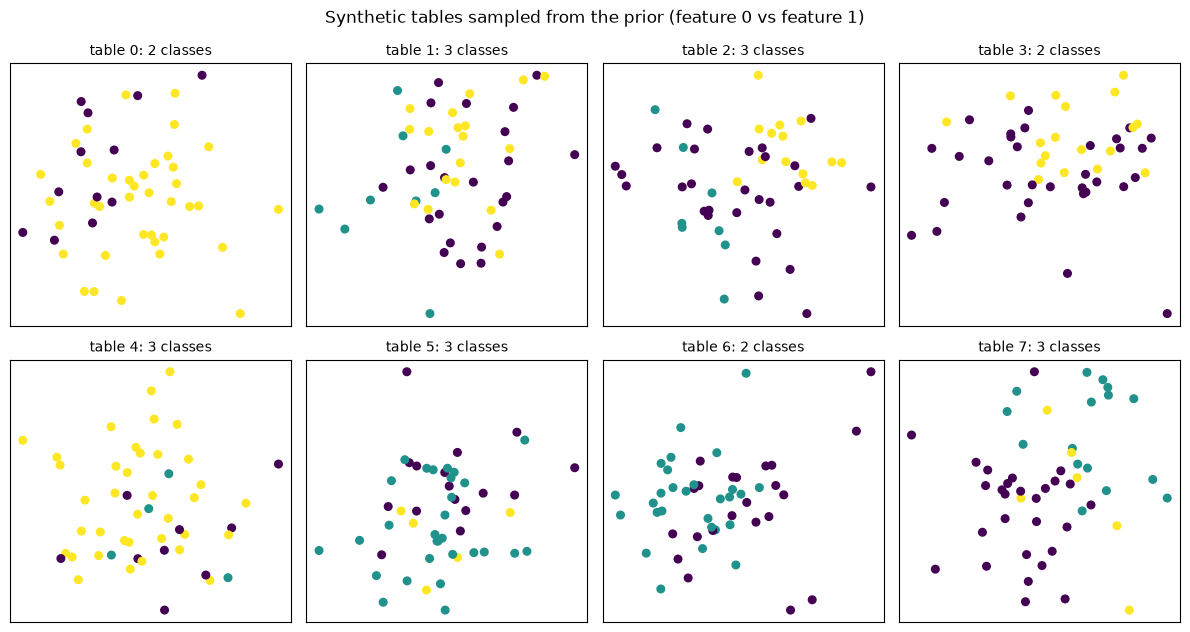

In [4]:
def show_prior_samples(batch, n=8):
    fig, axes = plt.subplots(2, n // 2, figsize=(3.2 * n // 2, 6.4))
    for i, ax in enumerate(axes.ravel()):
        x, y = batch["x"][i].numpy(), batch["y"][i].numpy()
        ax.scatter(x[:, 0], x[:, 1], c=y, cmap="viridis", s=30, vmin=0, vmax=MAX_CLASSES - 1)
        ax.set_title(f"table {i}: {len(np.unique(y))} classes", fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle("Synthetic tables sampled from the prior (feature 0 vs feature 1)")
    plt.tight_layout(); plt.show()


show_prior_samples(sample_prior_batch(8, gen=torch.Generator().manual_seed(1)))

## The architecture: a transformer over table cells

nanoTabPFN embeds **every cell** of the table into a vector, so a table becomes a tensor of shape
`(batch, rows, columns, embedding)`. The target column is appended as one more column; for the rows we want to predict,
the target is unknown and gets padded with the mean of the known targets.

Each transformer block then applies attention in **two directions**:

* **between features** – for every row, cells attend to the other cells of the same row (which columns matter?),
* **between datapoints** – for every column, rows attend to the *labelled* rows (which training examples are similar to me?).

Test rows only ever attend to training rows, never to each other, so predictions are independent of the other test rows.
Finally a small MLP on the target-cell embedding of each test row produces the class logits.

The code below follows [nanoTabPFN](https://github.com/automl/nanotabpfn) closely, with the memory-chunking helper for large
tables removed. Parameter names are identical, so checkpoints trained with the
[TFM-Playground](https://github.com/automl/TFM-Playground) scripts load into this model as well.

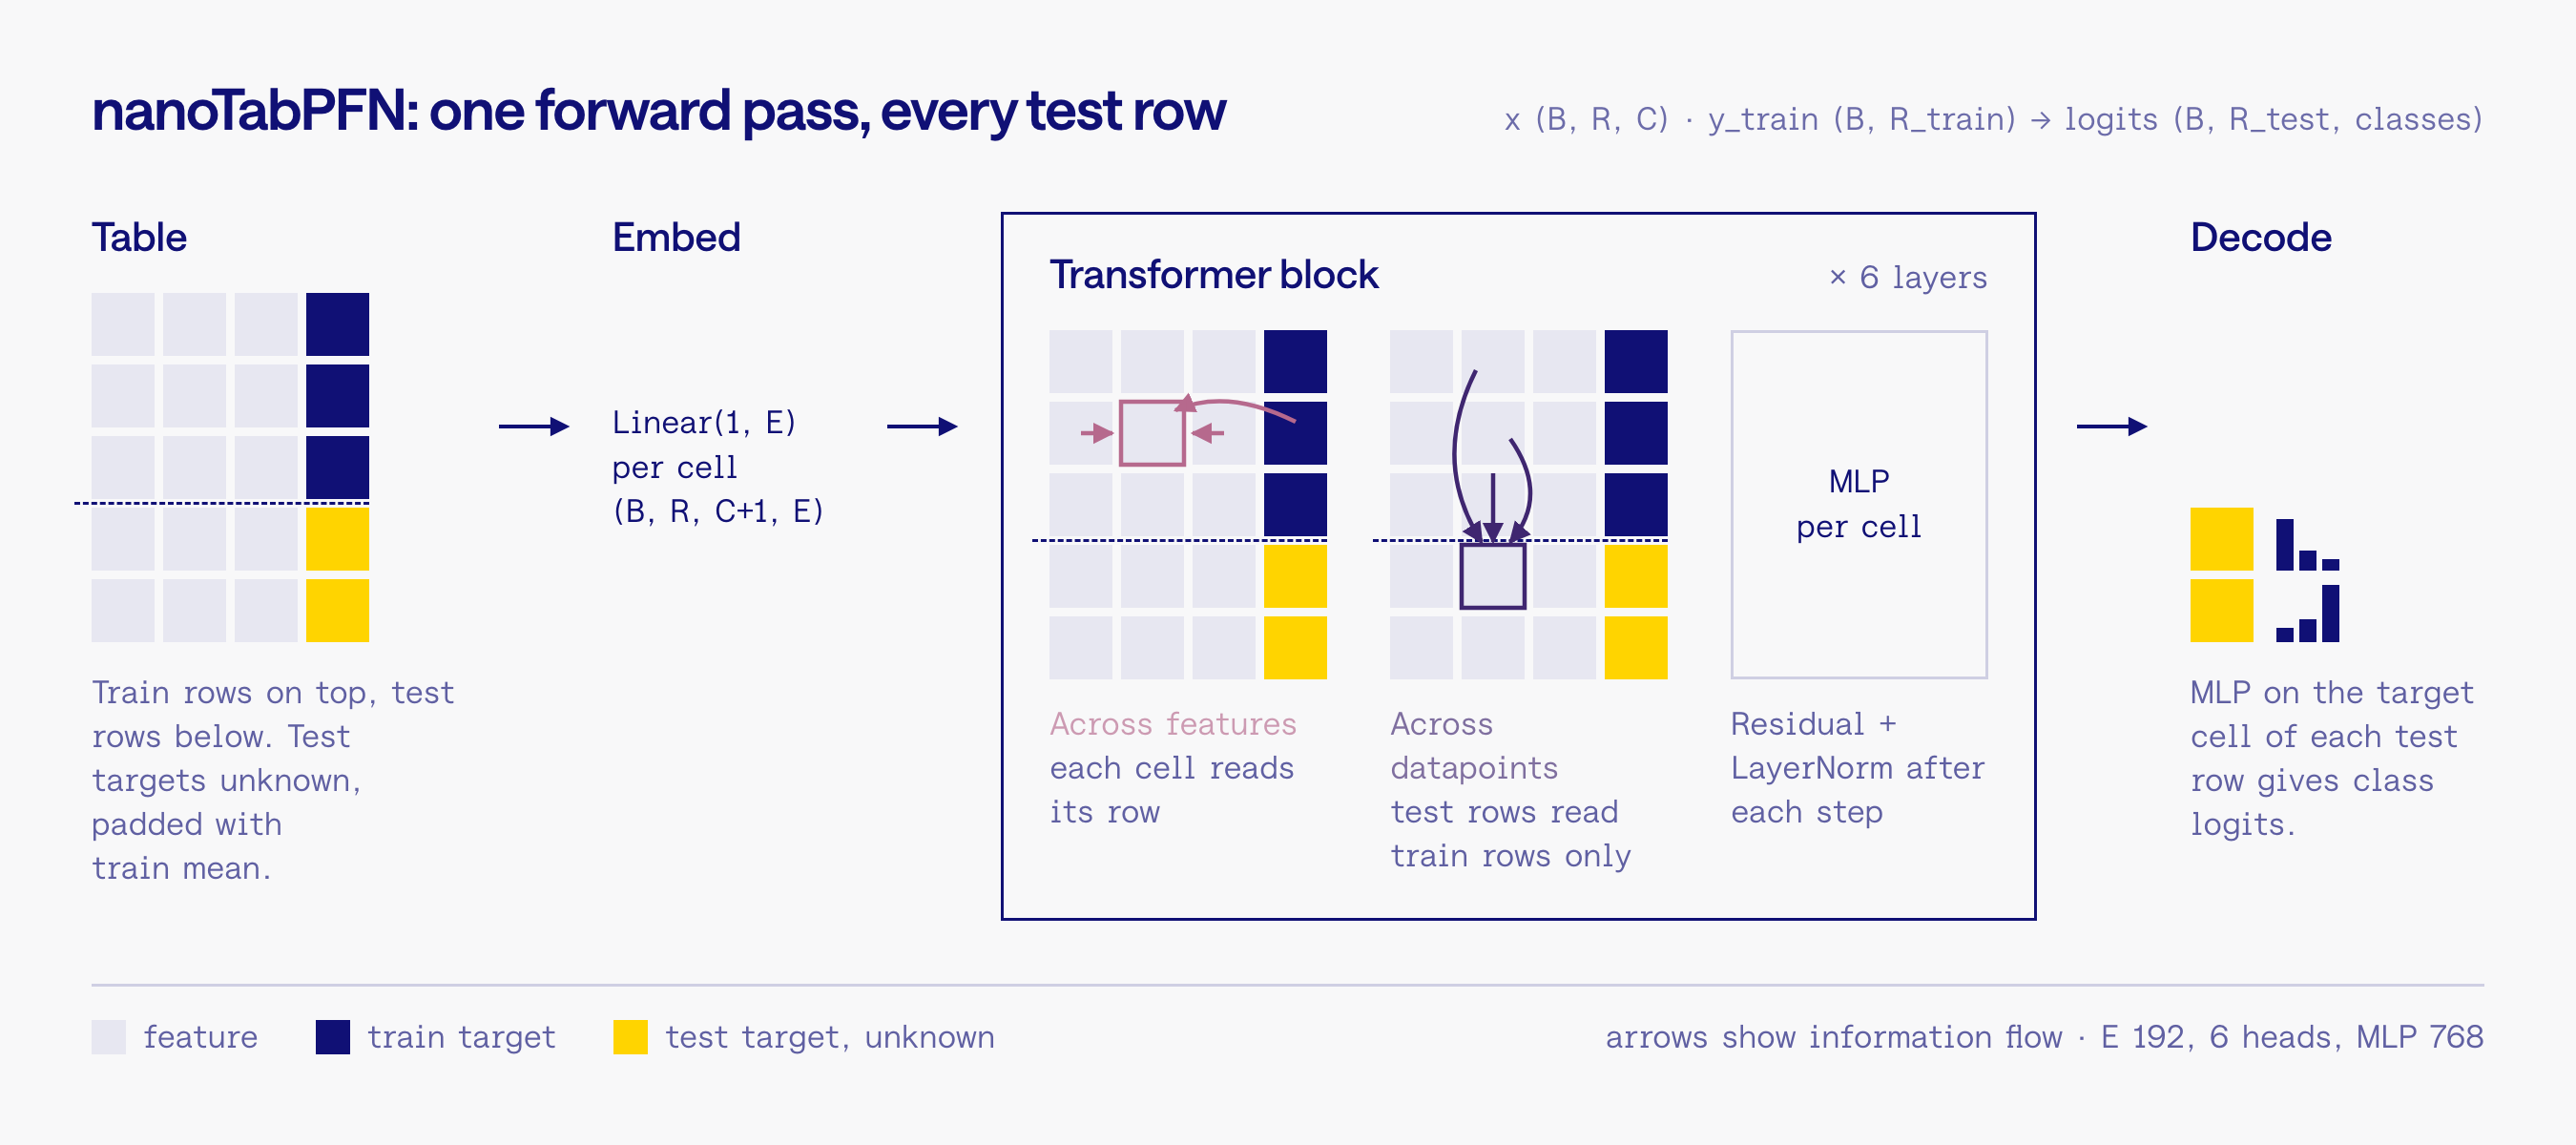

In [5]:
class FeatureEncoder(nn.Module):
    '''Standardises each feature using the training rows, then embeds each scalar cell with a linear layer.'''

    def __init__(self, embedding_size):
        super().__init__()
        self.linear_layer = nn.Linear(1, embedding_size)

    def forward(self, x, train_test_split_index):
        x = x.unsqueeze(-1)  # (B, R, C, 1)
        mean = x[:, :train_test_split_index].mean(dim=1, keepdim=True)
        std = x[:, :train_test_split_index].std(dim=1, keepdim=True) + 1e-8
        x = torch.clip((x - mean) / std, -100, 100)
        return self.linear_layer(x)  # (B, R, C, E)


class TargetEncoder(nn.Module):
    '''Pads the unknown targets of the test rows with the training mean, then embeds every target cell.'''

    def __init__(self, embedding_size):
        super().__init__()
        self.linear_layer = nn.Linear(1, embedding_size)

    def forward(self, y_train, num_rows):
        mean = y_train.mean(dim=1, keepdim=True)
        padding = mean.repeat(1, num_rows - y_train.shape[1], 1)
        y = torch.cat([y_train, padding], dim=1).unsqueeze(-1)  # (B, R, 1, 1)
        return self.linear_layer(y)  # (B, R, 1, E)


class TransformerEncoderLayer(nn.Module):
    '''Attention between features, attention between datapoints, then an MLP. Each with residual + LayerNorm.'''

    def __init__(self, embedding_size, nhead, mlp_hidden_size):
        super().__init__()
        self.self_attention_between_datapoints = nn.MultiheadAttention(embedding_size, nhead, batch_first=True)
        self.self_attention_between_features = nn.MultiheadAttention(embedding_size, nhead, batch_first=True)
        self.linear1 = nn.Linear(embedding_size, mlp_hidden_size)
        self.linear2 = nn.Linear(mlp_hidden_size, embedding_size)
        self.norm1 = nn.LayerNorm(embedding_size)
        self.norm2 = nn.LayerNorm(embedding_size)
        self.norm3 = nn.LayerNorm(embedding_size)

    def forward(self, src, train_test_split_index):
        B, R, C, E = src.shape
        # --- attention between features: every row is a sequence of C cells
        src = src.reshape(B * R, C, E)
        src = self.self_attention_between_features(src, src, src)[0] + src
        src = self.norm1(src.reshape(B, R, C, E))
        # --- attention between datapoints: every column is a sequence of R cells
        src = src.transpose(1, 2).reshape(B * C, R, E)
        train, test = src[:, :train_test_split_index], src[:, train_test_split_index:]
        train_out = self.self_attention_between_datapoints(train, train, train)[0]  # train rows attend to train rows
        test_out = self.self_attention_between_datapoints(test, train, train)[0]  # test rows attend to train rows only
        src = torch.cat([train_out, test_out], dim=1) + src
        src = self.norm2(src.reshape(B, C, R, E).transpose(1, 2))
        # --- position-wise MLP
        src = self.linear2(F.gelu(self.linear1(src))) + src
        return self.norm3(src)


class Decoder(nn.Module):
    def __init__(self, embedding_size, mlp_hidden_size, num_outputs):
        super().__init__()
        self.linear1 = nn.Linear(embedding_size, mlp_hidden_size)
        self.linear2 = nn.Linear(mlp_hidden_size, num_outputs)

    def forward(self, x):
        return self.linear2(F.gelu(self.linear1(x)))


class NanoTabPFNModel(nn.Module):
    def __init__(self, embedding_size, num_attention_heads, mlp_hidden_size, num_layers, num_outputs):
        super().__init__()
        self.feature_encoder = FeatureEncoder(embedding_size)
        self.target_encoder = TargetEncoder(embedding_size)
        self.transformer_blocks = nn.ModuleList(
            [TransformerEncoderLayer(embedding_size, num_attention_heads, mlp_hidden_size) for _ in range(num_layers)]
        )
        self.decoder = Decoder(embedding_size, mlp_hidden_size, num_outputs)

    def forward(self, x, y_train, train_test_split_index):
        '''
        x:       (B, R, C) all rows, training rows first
        y_train: (B, train_test_split_index) labels of the training rows
        returns: (B, R - train_test_split_index, num_outputs) logits for the test rows
        '''
        if y_train.dim() == 2:
            y_train = y_train.unsqueeze(-1)
        x_emb = self.feature_encoder(x, train_test_split_index)  # (B, R, C, E)
        y_emb = self.target_encoder(y_train, x.shape[1])  # (B, R, 1, E)
        src = torch.cat([x_emb, y_emb], dim=2)  # (B, R, C+1, E)
        for block in self.transformer_blocks:
            src = block(src, train_test_split_index)
        return self.decoder(src[:, train_test_split_index:, -1, :])  # target cells of the test rows


def make_model(num_outputs=MAX_CLASSES):
    return NanoTabPFNModel(embedding_size=192, num_attention_heads=6, mlp_hidden_size=768, num_layers=6, num_outputs=num_outputs)


model = make_model().to(device)
print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.2f} M parameters")

3.71 M parameters


### Following the tensor shapes

The same picture in numbers. Forward hooks print the shape at every stage for one small batch. Watch how the table is
flattened one way for attention between features (`B*R` sequences of length `C+1`) and the other way for attention between
datapoints (`B*(C+1)` sequences of length `R`). The datapoint attention is called twice per block: once for the train rows
attending to themselves and once for the test rows attending to the train rows.

In [6]:
def trace_shapes(model, x, y_train, split):
    # Registers forward hooks that print the tensor shape at every stage of one forward pass.
    print(f"input x {tuple(x.shape)} = (B, R, C) | y_train {tuple(y_train.shape)} | train_test_split_index = {split}\n")
    handles = []

    def log(name):
        def hook(module, inputs, output):
            out = output[0] if isinstance(output, tuple) else output
            print(f"{name:58s} in {str(tuple(inputs[0].shape)):18s} -> out {tuple(out.shape)}")
        return hook

    block = model.transformer_blocks[0]
    handles.append(model.feature_encoder.register_forward_hook(log("feature_encoder  (B, R, C, E)")))
    handles.append(model.target_encoder.register_forward_hook(log("target_encoder   (B, R, 1, E)")))
    handles.append(block.self_attention_between_features.register_forward_hook(log("  block 0: attention between features   (B*R, C+1, E)")))
    handles.append(block.self_attention_between_datapoints.register_forward_hook(log("  block 0: attention between datapoints (B*(C+1), rows, E)")))
    handles.append(block.register_forward_hook(log("block 0 output   (B, R, C+1, E)")))
    handles.append(model.decoder.register_forward_hook(log("decoder          (B, R - split, classes)")))
    with torch.no_grad():
        model(x, y_train, train_test_split_index=split)
    for h in handles:
        h.remove()


demo = sample_prior_batch(2, gen=torch.Generator().manual_seed(3))
split = demo["train_test_split_index"]
trace_shapes(model, demo["x"].to(device), demo["y"][:, :split].to(device), split)

input x (2, 50, 3) = (B, R, C) | y_train (2, 37) | train_test_split_index = 37



feature_encoder  (B, R, C, E)                              in (2, 50, 3)         -> out (2, 50, 3, 192)
target_encoder   (B, R, 1, E)                              in (2, 37, 1)         -> out (2, 50, 1, 192)
  block 0: attention between features   (B*R, C+1, E)      in (100, 4, 192)      -> out (100, 4, 192)
  block 0: attention between datapoints (B*(C+1), rows, E) in (8, 37, 192)       -> out (8, 37, 192)
  block 0: attention between datapoints (B*(C+1), rows, E) in (8, 13, 192)       -> out (8, 13, 192)
block 0 output   (B, R, C+1, E)                            in (2, 50, 4, 192)    -> out (2, 50, 4, 192)
decoder          (B, R - split, classes)                   in (2, 13, 192)       -> out (2, 13, 3)


## In-context inference: a scikit-learn style wrapper

There is no training at `fit` time. `fit` just stores the data; `predict_proba` concatenates training and test rows into
one table, runs a **single forward pass**, and applies a softmax to the logits of the test rows.

In [7]:
class NanoTabPFNClassifier:
    def __init__(self, model, device=device):
        self.model, self.device = model.to(device), device

    def fit(self, X_train, y_train):
        self.X_train = np.asarray(X_train, dtype=np.float32)
        self.y_train = np.asarray(y_train, dtype=np.float32)
        self.num_classes = int(self.y_train.max()) + 1
        return self

    def predict_proba(self, X_test):
        x = np.concatenate([self.X_train, np.asarray(X_test, dtype=np.float32)])
        x = torch.from_numpy(x).unsqueeze(0).to(self.device)  # batch of one table
        y = torch.from_numpy(self.y_train).unsqueeze(0).to(self.device)
        self.model.eval()
        with torch.no_grad():
            logits = self.model(x, y, train_test_split_index=len(self.X_train)).squeeze(0)
        return F.softmax(logits[:, : self.num_classes], dim=1).cpu().numpy()

    def predict(self, X_test):
        return self.predict_proba(X_test).argmax(axis=1)

### Real evaluation datasets

Three classic small datasets, each split 50/50. The model has never seen any of them. Note that wine has 13 features and
breast cancer has 30, while the prior only ever produced 3-feature tables. Nothing in the architecture is tied to the
number of columns (attention runs over however many cells a row has), so the model can still be applied. Whether it
*works* there is an empirical question we answer below.

In [8]:
from sklearn.datasets import load_breast_cancer, load_iris, load_wine
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split


def load_eval_datasets(test_size=0.5, seed=42):
    datasets = {}
    for name, loader in [("iris", load_iris), ("wine", load_wine), ("breast_cancer", load_breast_cancer)]:
        X, y = loader(return_X_y=True)
        datasets[name] = train_test_split(X, y, test_size=test_size, random_state=seed, stratify=y)
    return datasets


EVAL_DATASETS = load_eval_datasets()
for name, (X_tr, X_te, y_tr, y_te) in EVAL_DATASETS.items():
    print(f"{name:14s} train {X_tr.shape}  test {X_te.shape}  classes {len(np.unique(y_tr))}")


def auc(y_true, proba):
    return roc_auc_score(y_true, proba[:, 1] if proba.shape[1] == 2 else proba, multi_class="ovr")


def evaluate(clf, datasets=EVAL_DATASETS):
    '''Returns {dataset: ROC AUC} for any classifier with fit / predict_proba.'''
    return {name: auc(y_te, clf.fit(X_tr, y_tr).predict_proba(X_te)) for name, (X_tr, X_te, y_tr, y_te) in datasets.items()}


def mean_auc(scores):
    return float(np.mean(list(scores.values())))


untrained = evaluate(NanoTabPFNClassifier(model))
print("\nuntrained nanoTabPFN ROC AUC:", {k: round(v, 3) for k, v in untrained.items()}, "| mean", round(mean_auc(untrained), 3))

iris           train (75, 4)  test (75, 4)  classes 3
wine           train (89, 13)  test (89, 13)  classes 3
breast_cancer  train (284, 30)  test (285, 30)  classes 2



untrained nanoTabPFN ROC AUC: {'iris': 0.504, 'wine': 0.432, 'breast_cancer': 0.04} | mean 0.325


An untrained model is at chance level *or worse*: a randomly initialised network is not neutral, it computes some arbitrary
function of the inputs, and on breast cancer that function happens to be anti-correlated with the label. Now let's teach it.

## Pretraining

The loop is standard supervised learning with a twist: every step samples a fresh batch of tables, feeds the labelled rows
plus the unlabelled features through the model, and applies cross-entropy on the **test rows only**.
Because the model sees the labelled rows *inside its input*, minimising this loss means learning to do in-context prediction.

We use AdamW in its *schedule-free* variant so we don't need a learning-rate schedule, plus gradient clipping.
After every epoch we evaluate on the three real datasets; watch synthetic loss go down and real-data AUC go up.

With the default settings (80 epochs x 25 steps x 50 tables = 100k synthetic tables) this takes about 4 minutes on an
Apple M4 Max and less on a recent NVIDIA GPU. On a CPU-only runtime expect considerably longer. Real-data AUC is typically
above 0.9 after 5 epochs and saturates around epoch 30, so feel free to stop early with the interrupt button; the model and
the history so far are kept. Progress is printed every 5 epochs.

In [9]:
import schedulefree


def train(model, epochs, steps_per_epoch, batch_size, lr, log_every=5):
    optimizer = schedulefree.AdamWScheduleFree(model.parameters(), lr=lr, weight_decay=0.0)
    criterion = nn.CrossEntropyLoss()
    history = {"epoch": [], "loss": [], "auc": [], "per_dataset": []}

    try:
        for epoch in range(1, epochs + 1):
            t0 = time.time()
            model.train(); optimizer.train()
            total_loss = 0.0
            batches = prior_iterator(steps_per_epoch, batch_size, seed=SEED + epoch, device=device)
            for batch in batches:
                split = batch["train_test_split_index"]
                x, y = batch["x"], batch["y"]
                logits = model(x, y[:, :split], train_test_split_index=split)  # (B, R - split, classes)
                loss = criterion(logits.reshape(-1, logits.shape[-1]), y[:, split:].reshape(-1).long())
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                total_loss += loss.item()

            # --- end of epoch: evaluate on real data
            model.eval(); optimizer.eval()  # schedule-free: evaluate with the averaged weights
            scores = evaluate(NanoTabPFNClassifier(model))
            history["epoch"].append(epoch); history["loss"].append(total_loss / steps_per_epoch)
            history["auc"].append(mean_auc(scores)); history["per_dataset"].append(scores)
            if epoch == 1 or epoch % log_every == 0:
                print(f"epoch {epoch:3d} | {time.time() - t0:4.1f}s | prior loss {history['loss'][-1]:.3f} | "
                      f"real-data ROC AUC {history['auc'][-1]:.3f}  " + "  ".join(f"{k} {v:.3f}" for k, v in scores.items()), flush=True)
    except KeyboardInterrupt:
        print(f"interrupted during epoch {epoch}, keeping the model and history so far")
        model.eval(); optimizer.eval()
    return history


torch.manual_seed(SEED)  # same initialisation every time this cell runs
model = make_model().to(device)
history = train(model, EPOCHS, STEPS_PER_EPOCH, BATCH_SIZE, LR)

epoch   1 |  9.7s | prior loss 0.979 | real-data ROC AUC 0.349  iris 0.270  wine 0.729  breast_cancer 0.047


epoch   5 |  2.3s | prior loss 0.807 | real-data ROC AUC 0.882  iris 0.873  wine 0.812  breast_cancer 0.961


epoch  10 |  2.2s | prior loss 0.771 | real-data ROC AUC 0.891  iris 0.860  wine 0.854  breast_cancer 0.960


epoch  15 |  2.3s | prior loss 0.698 | real-data ROC AUC 0.941  iris 0.933  wine 0.922  breast_cancer 0.968


epoch  20 |  2.3s | prior loss 0.652 | real-data ROC AUC 0.965  iris 0.970  wine 0.949  breast_cancer 0.976


...

epoch  60 |  2.3s | prior loss 0.595 | real-data ROC AUC 0.985  iris 0.981  wine 0.990  breast_cancer 0.986


epoch  65 |  2.3s | prior loss 0.569 | real-data ROC AUC 0.985  iris 0.981  wine 0.991  breast_cancer 0.985


epoch  70 |  2.4s | prior loss 0.585 | real-data ROC AUC 0.986  iris 0.982  wine 0.990  breast_cancer 0.984


epoch  75 |  2.5s | prior loss 0.574 | real-data ROC AUC 0.986  iris 0.984  wine 0.991  breast_cancer 0.983


epoch  80 |  2.6s | prior loss 0.563 | real-data ROC AUC 0.986  iris 0.986  wine 0.990  breast_cancer 0.983


### Training curves

Left: cross-entropy on *synthetic* tables. Right: mean ROC AUC on the three *real* datasets. The model has never seen a
real row, yet the two curves move together.

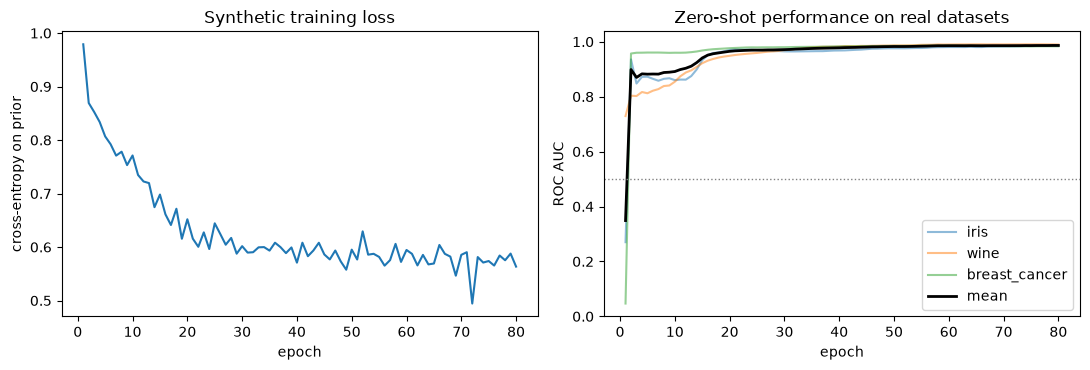

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.plot(history["epoch"], history["loss"]); ax1.set_xlabel("epoch"); ax1.set_ylabel("cross-entropy on prior"); ax1.set_title("Synthetic training loss")
for name in EVAL_DATASETS:
    ax2.plot(history["epoch"], [s[name] for s in history["per_dataset"]], alpha=0.5, label=name)
ax2.plot(history["epoch"], history["auc"], color="black", linewidth=2, label="mean")
ax2.axhline(0.5, color="gray", linestyle=":", linewidth=1)
ax2.set_xlabel("epoch"); ax2.set_ylabel("ROC AUC"); ax2.set_title("Zero-shot performance on real datasets"); ax2.legend()
plt.tight_layout(); plt.show()

## Before and after

Same splits, same metric, same weights up to the pretraining. `fit` never ran a gradient step on any of these datasets.

In [11]:
pretrained = evaluate(NanoTabPFNClassifier(model))
header = f"{'model':26s}" + "".join(f"{d:>15s}" for d in EVAL_DATASETS) + f"{'mean':>10s}"
print(header); print("-" * len(header))
for name, scores in [("nanoTabPFN (untrained)", untrained), ("nanoTabPFN (pretrained)", pretrained)]:
    print(f"{name:26s}" + "".join(f"{scores[d]:15.3f}" for d in EVAL_DATASETS) + f"{mean_auc(scores):10.3f}")

model                                iris           wine  breast_cancer      mean
---------------------------------------------------------------------------------
nanoTabPFN (untrained)              0.504          0.432          0.040     0.325
nanoTabPFN (pretrained)             0.986          0.990          0.983     0.986


## Ideas to experiment with

Everything in this notebook is a knob. Change one thing, rerun, compare the curve.

* **Prior**: sample the number of features per table (1 to 10) instead of fixing 3; add a second function family (random tree,
  Gaussian process, small causal graph) and mix them; use non-normal inputs (uniform, log-normal, categorical); add label noise,
  irrelevant columns, missing values, and up to 10 imbalanced classes.
* **Training**: vary the row count per batch (20 to 200); more steps per epoch, fewer epochs; sweep the learning rate and try a
  warmup and cosine schedule; larger batches.
* **Architecture**: 3 vs 12 layers; shuffle feature order during training and ensemble over permutations at inference; ablate
  one attention direction to see what it contributes; learned embedding for the unknown target instead of mean padding.
* **Evaluation**: more datasets; log loss next to ROC AUC for calibration; accuracy vs. number of context rows.

### References

* **nanoTabPFN** – minimal TabPFN v2 re-implementation this notebook is based on: [github.com/automl/nanotabpfn](https://github.com/automl/nanotabpfn)
* **TFM-Playground** – open playground for tabular foundation models with prior interfaces, pre-generated prior dumps,
  evaluation on TabArena and a regression variant: [github.com/automl/TFM-Playground](https://github.com/automl/TFM-Playground)
* Hollmann et al., *Accurate predictions on small data with a tabular foundation model*, Nature 2025 (TabPFN v2).
* Müller et al., *Transformers Can Do Bayesian Inference*, ICLR 2022 (prior-data fitted networks).